(chapter_8)=
# Scattering Curve Models

Following {cite:p}`Pedersen_1997`, we will glance over the models.

## Form Factors
### Homogeneous sphere

$$ F_1(q,R) = \frac{3[\sin(q R) - q R \cos(q R)]}{(q R)^3} $$

In [1]:
import sys
sys.path.insert(0, r'D:\Github\molass-library')
from molass import get_version
assert get_version() >= '0.0.9', 'Please update molass to the latest version'

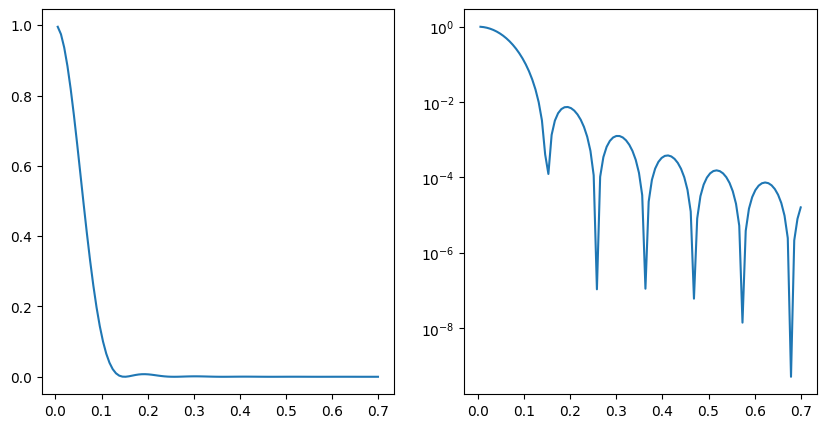

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from molass.CurveModels.Scattering.FormFactors import homogeneous_sphere

q = np.linspace(0.005, 0.7, 100)
R = 30

I = homogeneous_sphere(q, R)**2
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
ax2.set_yscale('log')
for ax in ax1, ax2:
    ax.plot(q, I, label='homogeneous sphere')

Text(0.5, 0, 'q (1/Å)')

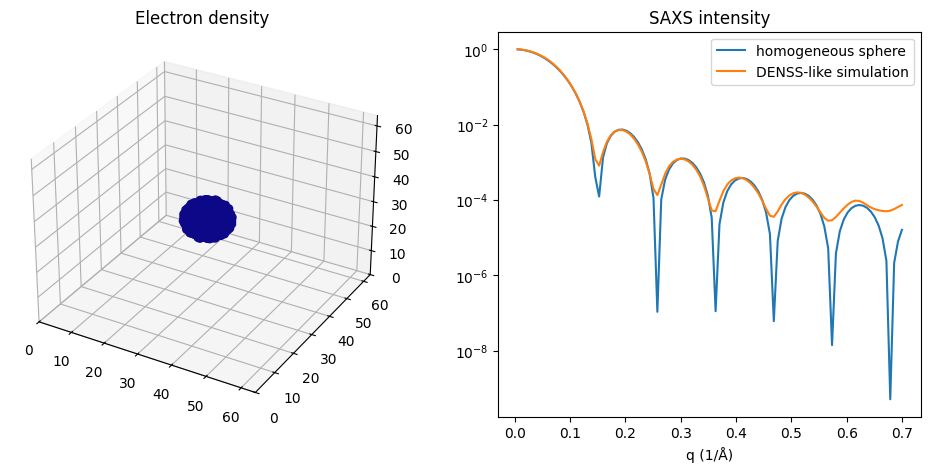

In [3]:
from molass.Shapes import Sphere
from molass.DensitySpace import VoxelSpace
from molass.SAXS.Simulator import compute_saxs

sphere = Sphere(radius=6.45)
space = VoxelSpace(64, sphere)
saxs = compute_saxs(space.rho, q=q)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title('Electron density')
space.plot_as_dots(ax1)

ax2 = fig.add_subplot(122)
ax2.set_title('SAXS intensity')
ax2.set_yscale('log')
ax2.plot(q, I, label='homogeneous sphere')
curve = saxs.get_curve()
ax2.plot(q, curve.y, label='DENSS-like simulation')
ax2.legend()
ax2.set_xlabel('q (1/Å)')

In [5]:
"""
from molass.CurveModels.Scattering.FormFactors import tri_axial_ellipsoid
I = tri_axial_ellipsoid(q, 7, 5, 3)**2
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))
ax2.set_yscale('log')
for ax in ax1, ax2:
    ax.plot(q, I, label='homogeneous sphere')
"""

"\nfrom molass.CurveModels.Scattering.FormFactors import tri_axial_ellipsoid\nI = tri_axial_ellipsoid(q, 7, 5, 3)**2\nfig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5))\nax2.set_yscale('log')\nfor ax in ax1, ax2:\n    ax.plot(q, I, label='homogeneous sphere')\n"

Text(0.5, 0, 'q (1/Å)')

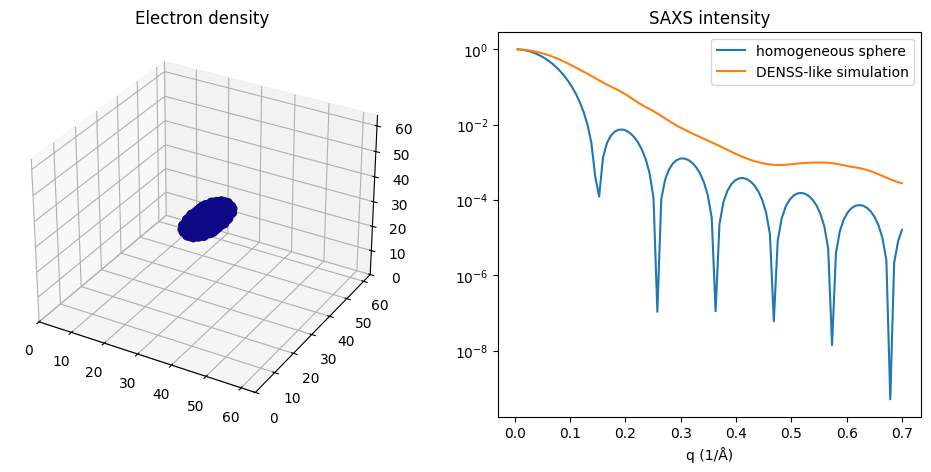

In [8]:
from molass.Shapes import Ellipsoid
from molass.DensitySpace import VoxelSpace
from molass.SAXS.Simulator import compute_saxs, draw_saxs

ellipsoid = Ellipsoid(10, 5, 3)
space = VoxelSpace(64, ellipsoid)
saxs = compute_saxs(space.rho)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title('Electron density')
space.plot_as_dots(ax1)

ax2 = fig.add_subplot(122)
ax2.set_title('SAXS intensity')
ax2.set_yscale('log')
ax2.plot(q, I, label='homogeneous sphere')
curve = saxs.get_curve()
ax2.plot(q, curve.y, label='DENSS-like simulation')
ax2.legend()
ax2.set_xlabel('q (1/Å)')